<a href="https://colab.research.google.com/github/JaaynyDasari/ecommerce-review-analytics/blob/master/Ecommerce_Review_and_Analytics_BDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing necessary packages : System packages and python packages.

In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-8-jdk-headless -qq
!pip install pyspark==3.4.1
!pip install vaderSentiment


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libxtst6:amd64.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package openjdk-8-jre-headless:amd64.
Preparing to unpack .../openjdk-8-jre-headless_8u472-ga-1~22.04_amd64.deb ...
Unpacking openjdk-8-jre-headless:amd64 (8u472-ga-1~22.04) ...
Selecting previously unselected package openjdk-8-jdk-headless:amd64.
Preparing to unpack .../openjdk-8-jdk-headless_8u472-ga-1~22.04_amd64.deb ...
Unpacking openjdk-8-jdk-headless:amd64 (8u472-ga-1~22.04) ...
Setting up libxtst6:amd64 (2:1.2.3-1build4) ...
Setting up openjdk-8-jre-headless:amd64 (8u472-ga-1~22.04) ...
update-alternatives: using /usr/lib/jvm

In [ ]:
# 0. Install Java and Hadoop
!apt-get update -qq
!apt-get install -y openjdk-8-jdk-headless -qq

!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf hadoop-3.3.6.tar.gz
!mv hadoop-3.3.6 /usr/local/hadoop


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os, textwrap, subprocess, pathlib

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/usr/local/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/usr/local/hadoop/etc/hadoop"
os.environ["PATH"] += ":/usr/local/hadoop/bin:/usr/local/hadoop/sbin"

# 1) Fix JAVA_HOME inside Hadoop config (this is what start-dfs.sh reads)
hadoop_env = "/usr/local/hadoop/etc/hadoop/hadoop-env.sh"
text = pathlib.Path(hadoop_env).read_text()
text = text.replace("# export JAVA_HOME=", f"export JAVA_HOME={os.environ['JAVA_HOME']}")
pathlib.Path(hadoop_env).write_text(text)

# 2) core-site.xml
core_site = textwrap.dedent("""
<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>hdfs://localhost:9000</value>
  </property>
</configuration>
""").strip()

open("/usr/local/hadoop/etc/hadoop/core-site.xml","w").write(core_site)

# 3) hdfs-site.xml
hdfs_site = textwrap.dedent("""
<configuration>
  <property>
    <name>dfs.replication</name>
    <value>1</value>
  </property>
  <property>
    <name>dfs.namenode.name.dir</name>
    <value>/usr/local/hadoop/hdfs/namenode</value>
  </property>
  <property>
    <name>dfs.datanode.data.dir</name>
    <value>/usr/local/hadoop/hdfs/datanode</value>
  </property>
</configuration>
""").strip()

open("/usr/local/hadoop/etc/hadoop/hdfs-site.xml","w").write(hdfs_site)


347

In [ ]:
!hdfs namenode -format -force


2025-11-30 07:27:52,261 INFO namenode.NameNode: STARTUP_MSG: 
/************************************************************
STARTUP_MSG: Starting NameNode
STARTUP_MSG:   host = b4a0eeea0d85/172.28.0.12
STARTUP_MSG:   args = [-format, -force]
STARTUP_MSG:   version = 3.3.6
STARTUP_MSG:   classpath = /usr/local/hadoop/etc/hadoop:/usr/local/hadoop/share/hadoop/common/lib/nimbus-jose-jwt-9.8.1.jar:/usr/local/hadoop/share/hadoop/common/lib/jetty-webapp-9.4.51.v20230217.jar:/usr/local/hadoop/share/hadoop/common/lib/netty-resolver-dns-native-macos-4.1.89.Final-osx-aarch_64.jar:/usr/local/hadoop/share/hadoop/common/lib/netty-codec-xml-4.1.89.Final.jar:/usr/local/hadoop/share/hadoop/common/lib/jcip-annotations-1.0-1.jar:/usr/local/hadoop/share/hadoop/common/lib/commons-compress-1.21.jar:/usr/local/hadoop/share/hadoop/common/lib/jackson-annotations-2.12.7.jar:/usr/local/hadoop/share/hadoop/common/lib/jetty-http-9.4.51.v20230217.jar:/usr/local/hadoop/share/hadoop/common/lib/jetty-xml-9.4.51.v2023

In [ ]:
!hdfs --daemon start namenode
!hdfs --daemon start datanode
!jps


3296 Jps
3265 DataNode
3197 NameNode


In [ ]:
!hdfs dfs -mkdir -p /data/amazon
!hdfs dfs -ls /


Found 1 items
drwxr-xr-x   - root supergroup          0 2025-11-30 07:28 /data


In [ ]:
!hdfs dfs -put -f /content/drive/MyDrive/AMAZON_FASHION.json /data/amazon/
!hdfs dfs -ls /data/amazon


put: `/content/drive/MyDrive/AMAZON_FASHION.json': No such file or directory


Configuring java environment and starting a spark session

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ShoppingReviewAnalysis") \
    .config("spark.driver.memory","4g") \
    .getOrCreate()

spark


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading dataset file and checking the schema.

In [ ]:
!hdfs getconf -confKey fs.defaultFS


hdfs://localhost:9000


In [ ]:
!hdfs --daemon start namenode
!hdfs --daemon start datanode
!jps


3632 SparkSubmit
18824 NameNode
18920 Jps
18890 DataNode


In [ ]:
spark.stop()


In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("ShoppingReviewAnalysis")
         .master("local[*]")
         .config("spark.hadoop.fs.defaultFS", "hdfs://0.0.0.0:9000")
         .config("spark.hadoop.hdfs.impl", "org.apache.hadoop.hdfs.DistributedFileSystem")
         .config("spark.hadoop.fs.hdfs.impl", "org.apache.hadoop.hdfs.DistributedFileSystem")
         .getOrCreate())


In [ ]:
!sed -i 's/localhost/0.0.0.0/g' $HADOOP_HOME/etc/hadoop/core-site.xml


In [ ]:
!hdfs getconf -confKey fs.defaultFS


hdfs://0.0.0.0:9000


In [ ]:
import os

# List the contents of your Google Drive's root folder
print("Contents of /content/drive/MyDrive/:")
print(os.listdir('/content/drive/MyDrive/'))

Contents of /content/drive/MyDrive/:
['Colab Notebooks', '2.gdoc', 'Untitled document (9).gdoc', 'Chemistry chemical kinetics word (1).docx', 'Chemistry chemical kinetics word.docx', 'Chemistry Seminar .gslides', 'Chapter 1 ._copy', 'chapter 2 geo._copy', 'Science (4)_copy.pdf', 'ISCP 11 8.gdoc', 'Basic stack programs. .gdoc', 'DE MANUAL.pdf', 'Untitled document (8).gdoc', 'Untitled document (7).gdoc', 'Copy of Untitled form.gform', 'Untitled form (1).gform', 'C++ PROJECT PRESENTATION.pptx', '14967175-preview.mp4', 'Untitled drawing.gdraw', 'Untitled document (6).gdoc', 'DS PROJECT - AP22110010753 - P.KARISHMA.docx', 'DS PROJECT - AP22110010755- CSE_L (1).gdoc', 'DS PROJECT - AP22110010755- CSE_L.docx', 'Funngro.gdoc', "JAAYNY'S WORK.gsheet", 'Resume (1).gdoc', 'Resume.gdoc', 'Untitled form.gform', 'RURAL VISIT ASSIGNMENT (1).gdoc', 'RURAL VISIT ASSIGNMENT.gdoc', 'Untitled document (5).gdoc', 'Untitled presentation (1).gslides', 'Untitled presentation.gslides', 'AP22110010755 - Jaayny 

In [ ]:
!hdfs dfs -ls /


Found 1 items
drwxr-xr-x   - root supergroup          0 2025-11-30 07:28 /data


In [ ]:
!hdfs dfs -ls /data


Found 1 items
drwxr-xr-x   - root supergroup          0 2025-11-30 07:28 /data/amazon


In [ ]:
!hdfs dfs -ls /data/amazon


In [ ]:
!hdfs dfs -du -h /data/amazon/AMAZON_FASHION.json


du: `/data/amazon/AMAZON_FASHION.json': No such file or directory


In [ ]:
!hdfs dfs -head /data/amazon/AMAZON_FASHION.json


head: `/data/amazon/AMAZON_FASHION.json': No such file or directory


In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("BigDataProject")
         .master("local[*]")
         .config("spark.hadoop.fs.defaultFS", "hdfs://0.0.0.0:9000")
         .config("spark.hadoop.hdfs.impl", "org.apache.hadoop.hdfs.DistributedFileSystem")
         .config("spark.hadoop.fs.hdfs.impl", "org.apache.hadoop.hdfs.DistributedFileSystem")
         .getOrCreate())

file_path = "hdfs://0.0.0.0:9000/data/amazon/AMAZON_FASHION.json"

df = spark.read.json(file_path)
df.show(5, truncate=False)


Py4JJavaError: An error occurred while calling o138.json.
: java.io.EOFException: End of File Exception between local host is: "b4a0eeea0d85/172.28.0.12"; destination host is: "0.0.0.0":9000; : java.io.EOFException; For more details see:  http://wiki.apache.org/hadoop/EOFException
	at sun.reflect.NativeConstructorAccessorImpl.newInstance0(Native Method)
	at sun.reflect.NativeConstructorAccessorImpl.newInstance(NativeConstructorAccessorImpl.java:62)
	at sun.reflect.DelegatingConstructorAccessorImpl.newInstance(DelegatingConstructorAccessorImpl.java:45)
	at java.lang.reflect.Constructor.newInstance(Constructor.java:423)
	at org.apache.hadoop.net.NetUtils.wrapWithMessage(NetUtils.java:913)
	at org.apache.hadoop.net.NetUtils.wrapException(NetUtils.java:862)
	at org.apache.hadoop.ipc.Client.getRpcResponse(Client.java:1616)
	at org.apache.hadoop.ipc.Client.call(Client.java:1558)
	at org.apache.hadoop.ipc.Client.call(Client.java:1455)
	at org.apache.hadoop.ipc.ProtobufRpcEngine2$Invoker.invok

In [ ]:
print(df.count())


883636


Counting rows and re-show samples/schema to ensure the DataFrame is ready for transformations.

In [ ]:
# confirm df is the DataFrame you printed earlier
print("Rows:", df.count())
df.show(5, truncate=120)
df.printSchema()


Rows: 883636
+----------+-----+-------+------------------------------------------------------------------------------------------------------------------------+-----------+--------------+------------+-----+-------------------------------------------------+--------------+--------+----+
|      asin|image|overall|                                                                                                              reviewText| reviewTime|    reviewerID|reviewerName|style|                                          summary|unixReviewTime|verified|vote|
+----------+-----+-------+------------------------------------------------------------------------------------------------------------------------+-----------+--------------+------------+-----+-------------------------------------------------+--------------+--------+----+
|7106116521| null|    5.0|                                                                                                  Exactly what I needed.|10 20, 2014|A1D4G1SNU

Selecting relevant columns and creating typed fields.

In [ ]:
from pyspark.sql.functions import from_unixtime, to_date, col
from pyspark.sql.types import DoubleType

df2 = df.select(
    col("asin"),
    col("overall").alias("rating"),
    col("reviewText"),
    col("summary"),
    col("reviewTime"),
    col("unixReviewTime"),
    col("verified"),
    col("reviewerID"),
    col("reviewerName")
)

# cast rating to double and create review_date from unixReviewTime
df2 = df2.withColumn("rating", col("rating").cast(DoubleType()))
df2 = df2.withColumn("review_date", to_date(from_unixtime(col("unixReviewTime"))))

df2.show(5, truncate=120)
df2.printSchema()


+----------+------+------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------+-----------+--------------+--------+--------------+------------+-----------+
|      asin|rating|                                                                                                              reviewText|                                          summary| reviewTime|unixReviewTime|verified|    reviewerID|reviewerName|review_date|
+----------+------+------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------+-----------+--------------+--------+--------------+------------+-----------+
|7106116521|   5.0|                                                                                                  Exactly what I needed.|                           perfect replacements!!|10 20, 20

Removing rows with null/empty reviewText to avoid processing useless data and reducing processing overhead.

In [ ]:
# drop rows where reviewText is null or empty
from pyspark.sql.functions import trim, length

df2 = df2.filter(col("reviewText").isNotNull()) \
         .filter(length(trim(col("reviewText"))) > 0)

print("Rows after dropping empty reviews:", df2.count())


Rows after dropping empty reviews: 882402


Performing basic EDA to understand the dataset shape and distribution.

In [ ]:
from pyspark.sql.functions import count, desc, year, date_format, avg

# rating distribution
df2.groupBy("rating").count().orderBy("rating").show()

# top 10 products by review count
df2.groupBy("asin").agg(count("*").alias("reviews")) \
   .orderBy(desc("reviews")).show(10)

# reviews per year
df2.withColumn("year", date_format(col("review_date"), "yyyy")) \
   .groupBy("year").count().orderBy("year").show()

# average rating by year (trend)
df2.withColumn("year", date_format(col("review_date"), "yyyy")) \
   .groupBy("year").agg(avg("rating").alias("avg_rating")).orderBy("year").show()


+------+------+
|rating| count|
+------+------+
|   1.0|106984|
|   2.0| 64690|
|   3.0| 96969|
|   4.0|149169|
|   5.0|464590|
+------+------+

+----------+-------+
|      asin|reviews|
+----------+-------+
|B000V0IBDM|   4380|
|B000KPIHQ4|   4371|
|B00I0VHS10|   3884|
|B00RLSCLJM|   3633|
|B000PHANNM|   2566|
|B000YFSR5G|   2534|
|B00201ER88|   2202|
|B00GXE331K|   2025|
|B000P0X15G|   1924|
|B00XT15P8E|   1855|
+----------+-------+
only showing top 10 rows

+----+------+
|year| count|
+----+------+
|2002|     5|
|2003|    19|
|2004|    52|
|2005|   154|
|2006|   329|
|2007|  1479|
|2008|  1825|
|2009|  2123|
|2010|  2369|
|2011|  3412|
|2012|  8216|
|2013| 26813|
|2014| 90260|
|2015|200550|
|2016|313158|
|2017|173773|
|2018| 57865|
+----+------+

+----+------------------+
|year|        avg_rating|
+----+------------------+
|2002|               4.2|
|2003|4.2631578947368425|
|2004|3.8846153846153846|
|2005|3.5844155844155843|
|2006| 4.051671732522796|
|2007|4.0872210953346855|
|2008|

Adding "review_len" to detect extremely short or verbose reviews.

In [ ]:
from pyspark.sql.functions import length

df2 = df2.withColumn("review_len", length(col("reviewText")))
df2.select("asin","rating","review_len").orderBy(desc("review_len")).show(5)


+----------+------+----------+
|      asin|rating|review_len|
+----------+------+----------+
|B01GYLUZLC|   5.0|     10565|
|B00TFSEKMM|   5.0|      9461|
|B00K8UVPM4|   4.0|      7398|
|B000UJA696|   5.0|      6688|
|B000UJDPHQ|   5.0|      6688|
+----------+------+----------+
only showing top 5 rows



In [ ]:
# save a 50k-row sample to drive as CSV for quick pandas plotting if needed
sample_df = df2.sample(False, 0.05, seed=42)   # ~5% sample; adjust fraction to get ~50k
sample_df.coalesce(1).write.option("header","true").csv("/content/drive/MyDrive/amazon_fashion_sample_csv")


Preparing VADER sentiment UDFs.

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql.types import DoubleType, StringType
from pyspark.sql.functions import udf, col

analyzer = SentimentIntensityAnalyzer()

def get_compound(text):
    if text is None:
        return 0.0
    return float(analyzer.polarity_scores(text)['compound'])

def get_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

compound_udf = udf(get_compound, DoubleType())
label_udf = udf(get_label, StringType())


Adding sentiment_score and sentiment_label columns to each review using the UDFs.

In [ ]:
df2 = df2.withColumn("sentiment_score", compound_udf(col("reviewText")))
df2 = df2.withColumn("sentiment_label", label_udf(col("sentiment_score")))

df2.select("reviewText", "sentiment_score", "sentiment_label").show(5, truncate=80)


+--------------------------------------------------------------------------------+---------------+---------------+
|                                                                      reviewText|sentiment_score|sentiment_label|
+--------------------------------------------------------------------------------+---------------+---------------+
|                                                          Exactly what I needed.|            0.0|        neutral|
|I agree with the other review, the opening is too small.  I almost bent the h...|         0.1901|       positive|
|Love these... I am going to order another pack to keep in work; someone (incl...|         0.8074|       positive|
|                                                             too tiny an opening|            0.0|        neutral|
|                                                                            Okay|         0.2263|       positive|
+-------------------------------------------------------------------------------

Displaying counts of positive/neutral/negative reviews to get a quick sentiment overview.

In [ ]:
df2.groupBy("sentiment_label").count().show()


+---------------+------+
|sentiment_label| count|
+---------------+------+
|       positive|692146|
|        neutral| 88046|
|       negative|102210|
+---------------+------+



Deriving year and year_month strings from review_date for time-series grouping.

In [ ]:
from pyspark.sql.functions import date_format

df2 = df2.withColumn("year", date_format(col("review_date"), "yyyy")) \
         .withColumn("year_month", date_format(col("review_date"), "yyyy-MM"))

df2.select("review_date", "year", "year_month").show(5)


+-----------+----+----------+
|review_date|year|year_month|
+-----------+----+----------+
| 2014-10-20|2014|   2014-10|
| 2014-09-28|2014|   2014-09|
| 2014-08-25|2014|   2014-08|
| 2014-08-24|2014|   2014-08|
| 2014-07-27|2014|   2014-07|
+-----------+----+----------+
only showing top 5 rows



Computing monthly average sentiment.

In [ ]:
monthly_sent = (df2.groupBy("year_month")
                     .avg("sentiment_score")
                     .orderBy("year_month"))

monthly_sent.show(20, truncate=False)


+----------+--------------------+
|year_month|avg(sentiment_score)|
+----------+--------------------+
|2002-11   |0.9496333333333333  |
|2002-12   |0.94005             |
|2003-01   |0.7106              |
|2003-02   |0.34655             |
|2003-03   |0.6568999999999999  |
|2003-05   |0.9476              |
|2003-06   |0.9685              |
|2003-07   |0.81655             |
|2003-11   |0.8760666666666667  |
|2003-12   |0.8897166666666667  |
|2004-01   |0.696725            |
|2004-02   |0.72685             |
|2004-03   |0.9196200000000001  |
|2004-04   |0.7907              |
|2004-05   |0.70165             |
|2004-06   |0.7455125           |
|2004-07   |0.3952166666666666  |
|2004-08   |0.1193              |
|2004-09   |0.90435             |
|2004-10   |0.47326666666666667 |
+----------+--------------------+
only showing top 20 rows



In [ ]:
monthly_pd = monthly_sent.toPandas()
monthly_pd.head()


,year_month,avg(sentiment_score)
0,2002-11,0.949633
1,2002-12,0.940050
2,2003-01,0.710600
3,2003-02,0.346550
4,2003-03,0.656900


Plotting yearly sentiment trend.

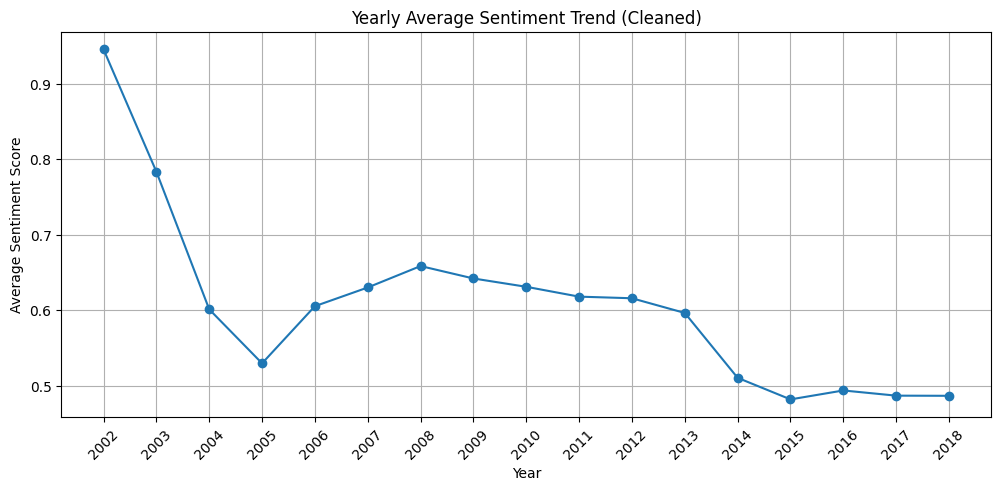

In [ ]:
yearly_sent = (df2.groupBy("year")
                    .avg("sentiment_score")
                    .orderBy("year"))

yearly_pd = yearly_sent.toPandas()

plt.figure(figsize=(12,5))
plt.plot(yearly_pd['year'], yearly_pd['avg(sentiment_score)'], marker='o')
plt.xticks(rotation=45)
plt.title("Yearly Average Sentiment Trend (Cleaned)")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.grid(True)
plt.show()


Computing review_count, avg_rating, and avg_sentiment per asin for business insights.

In [ ]:
from pyspark.sql.functions import avg, count, desc

product_stats = (df2.groupBy("asin")
                 .agg(
                     count("*").alias("review_count"),
                     avg("rating").alias("avg_rating"),
                     avg("sentiment_score").alias("avg_sentiment")
                 )
                 .orderBy(desc("review_count"))
                )

product_stats.show(10, truncate=False)


+----------+------------+-----------------+-------------------+
|asin      |review_count|avg_rating       |avg_sentiment      |
+----------+------------+-----------------+-------------------+
|B000V0IBDM|4380        |4.516666666666667|0.47503627853881175|
|B000KPIHQ4|4371        |4.518874399450927|0.4750850148707378 |
|B00I0VHS10|3884        |4.44335736354274 |0.6978755664263654 |
|B00RLSCLJM|3633        |4.826314340765208|0.698845499587114  |
|B000PHANNM|2566        |4.654715510522213|0.6595491426344491 |
|B000YFSR5G|2534        |3.796764009471192|0.3622289265982632 |
|B00201ER88|2202        |4.422797456857403|0.6394569936421431 |
|B00GXE331K|2025        |4.23358024691358 |0.5594021728395061 |
|B000P0X15G|1924        |4.412162162162162|0.6305525987525985 |
|B00XT15P8E|1855        |4.72722371967655 |0.6557986522911056 |
+----------+------------+-----------------+-------------------+
only showing top 10 rows



Displaying the top reviewed products.

In [ ]:
top_reviewed = product_stats.orderBy(desc("review_count")).limit(10)
top_reviewed.show(truncate=False)


+----------+------------+-----------------+-------------------+
|asin      |review_count|avg_rating       |avg_sentiment      |
+----------+------------+-----------------+-------------------+
|B000V0IBDM|4380        |4.516666666666667|0.47503627853881175|
|B000KPIHQ4|4371        |4.518874399450927|0.4750850148707378 |
|B00I0VHS10|3884        |4.44335736354274 |0.6978755664263654 |
|B00RLSCLJM|3633        |4.826314340765208|0.698845499587114  |
|B000PHANNM|2566        |4.654715510522213|0.6595491426344491 |
|B000YFSR5G|2534        |3.796764009471192|0.3622289265982632 |
|B00201ER88|2202        |4.422797456857403|0.6394569936421431 |
|B00GXE331K|2025        |4.23358024691358 |0.5594021728395061 |
|B000P0X15G|1924        |4.412162162162162|0.6305525987525985 |
|B00XT15P8E|1855        |4.72722371967655 |0.6557986522911056 |
+----------+------------+-----------------+-------------------+



Filtering products with ≥100 reviews and show those with highest average sentiment.

In [ ]:
best_products = (product_stats
                 .filter(product_stats.review_count >= 100)
                 .orderBy(desc("avg_sentiment"))
                 .limit(10)
                )

best_products.show(truncate=False)


+----------+------------+-----------------+------------------+
|asin      |review_count|avg_rating       |avg_sentiment     |
+----------+------------+-----------------+------------------+
|B0006HB4XE|254         |4.858267716535433|0.8309401574803151|
|B00EW4L7GG|144         |4.548611111111111|0.7904145833333333|
|B000XA9YMM|266         |4.646616541353383|0.7573733082706767|
|B00ZDBVNIO|185         |4.508108108108108|0.7539886486486481|
|B018TNFNGA|164         |4.676829268292683|0.7521878048780487|
|B000W5QFAW|118         |4.5              |0.7496050847457626|
|B0148B7EJ6|141         |4.907801418439717|0.7464971631205674|
|B01B5BWTNS|529         |4.844990548204159|0.7436247637051048|
|B0092SVT6U|124         |4.701612903225806|0.7379298387096773|
|B00NFR7UNK|249         |4.542168674698795|0.7377477911646585|
+----------+------------+-----------------+------------------+



Similarly, listing products with lowest average sentiment for action items.

In [ ]:
worst_products = (product_stats
                  .filter(product_stats.review_count >= 100)
                  .orderBy("avg_sentiment")  # ascending
                  .limit(10)
                 )

worst_products.show(truncate=False)


+----------+------------+------------------+---------------------+
|asin      |review_count|avg_rating        |avg_sentiment        |
+----------+------------+------------------+---------------------+
|B00928XTRC|145         |1.013793103448276 |-0.498008275862069   |
|B00NKX7ULQ|121         |1.6611570247933884|-0.0998190082644628  |
|B012C1WB3S|143         |1.916083916083916 |-0.006307692307692307|
|B00K85HB5Y|107         |2.682242990654206 |0.06882803738317757  |
|B00C2BZCD0|150         |1.6333333333333333|0.07203333333333335  |
|B017X9JBXW|213         |2.1737089201877935|0.07723286384976528  |
|B019F75KZ8|188         |2.372340425531915 |0.08051968085106383  |
|B01B5JRR4G|129         |2.317829457364341 |0.1072782945736434   |
|B00MHDY7F2|163         |2.2822085889570554|0.1382263803680982   |
|B00HHJJ4PY|174         |2.718390804597701 |0.1629747126436782   |
+----------+------------+------------------+---------------------+



Calculating Pearson correlation between numeric rating and sentiment_score to validate alignment.

In [ ]:
from pyspark.sql.functions import corr

df2.select(corr("rating", "sentiment_score")).show()


+-----------------------------+
|corr(rating, sentiment_score)|
+-----------------------------+
|           0.6216113565102457|
+-----------------------------+



Group by rating to compute average sentiment and review counts per star level.

In [ ]:
rating_sent = (df2.groupBy("rating")
               .agg(
                   avg("sentiment_score").alias("avg_sentiment"),
                   count("*").alias("review_count")
               )
               .orderBy("rating"))

rating_sent.show()


+------+--------------------+------------+
|rating|       avg_sentiment|review_count|
+------+--------------------+------------+
|   1.0|-0.09839311485830056|      106984|
|   2.0|  0.1039363951151649|       64690|
|   3.0|  0.3207868040301623|       96969|
|   4.0|   0.588389236369489|      149169|
|   5.0|  0.6964497589270969|      464590|
+------+--------------------+------------+



Plotted rating vs avg sentiment

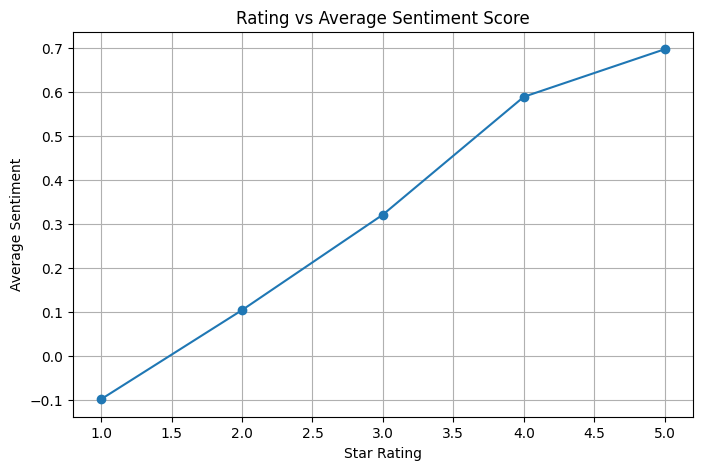

In [ ]:
rating_sent_pd = rating_sent.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(rating_sent_pd['rating'], rating_sent_pd['avg_sentiment'], marker='o')
plt.title("Rating vs Average Sentiment Score")
plt.xlabel("Star Rating")
plt.ylabel("Average Sentiment")
plt.grid(True)
plt.show()


Preparing negative-review sample for LDA.

In [ ]:
from pyspark.sql.functions import col

neg_df = df2.filter(col("sentiment_label") == "negative").select("reviewText").na.drop()

# sample for LDA (Spark can handle 100k+, but we use ~40k for speed)
neg_sample = neg_df.sample(False, 0.4, seed=42)
neg_sample.count()


40980

Tokenizing text, removing stopwords, building CountVectorizer, and creating features for LDA input.

In [ ]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer

tokenizer = RegexTokenizer(inputCol="reviewText", outputCol="tokens", pattern="\\W")
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered")
cv = CountVectorizer(inputCol="filtered", outputCol="features", vocabSize=5000, minDF=10)

tokenized = tokenizer.transform(neg_sample)
filtered = remover.transform(tokenized)
cv_model = cv.fit(filtered)
cv_data = cv_model.transform(filtered)


Fitting LDA on negative reviews.

In [ ]:
from pyspark.ml.clustering import LDA

lda = LDA(k=6, maxIter=10)
lda_model = lda.fit(cv_data)

topics = lda_model.describeTopics(10)
vocab = cv_model.vocabulary

topics.show()


+-----+--------------------+--------------------+
|topic|         termIndices|         termWeights|
+-----+--------------------+--------------------+
|    0|[247, 361, 13, 24...|[0.00797925092542...|
|    1|[18, 29, 5, 26, 3...|[0.01813693686700...|
|    2|[3, 0, 35, 9, 8, ...|[0.03418553901600...|
|    3|[40, 68, 1111, 58...|[0.00722663087012...|
|    4|[0, 5, 2, 12, 11,...|[0.01432663252826...|
|    5|[1, 2, 4, 0, 15, ...|[0.01974234977028...|
+-----+--------------------+--------------------+



Converting LDA term indices to actual words and printing interpretable negative topics.

In [ ]:
topic_words = []

for row in topics.collect():
    topic = row['topic']
    terms = row['termIndices']
    words = [vocab[idx] for idx in terms]
    topic_words.append((topic, words))

for topic, words in topic_words:
    print(f"\nTopic {topic}: {', '.join(words)}")



Topic 0: fake, cotton, ordered, pain, size, back, much, product, foot, quality

Topic 1: broke, money, one, time, first, waste, quality, disappointed, 2, apart

Topic 2: quality, like, poor, cheap, material, looks, picture, bad, horrible, product

Topic 3: color, wrong, images, turned, class, green, received, video, amazon, expected

Topic 4: like, one, size, get, picture, wear, back, look, good, made

Topic 5: small, size, fit, like, way, ordered, shirt, disappointed, material, dress


Preparing positive-review sample for LDA.

In [ ]:
from pyspark.sql.functions import col

# Select only positive reviews
pos_df = df2.filter(col("sentiment_label") == "positive").select("reviewText").na.drop()

# Sample to ~40-60k reviews for performance
pos_sample = pos_df.sample(False, 0.1, seed=42)
pos_sample.count()


69016

Applying same tokenizer/remover and CountVectorizer to positive sample to create LDA features.

In [ ]:
tokenized_pos = tokenizer.transform(pos_sample)
filtered_pos = remover.transform(tokenized_pos)
cv_model_pos = cv.fit(filtered_pos)
cv_data_pos = cv_model_pos.transform(filtered_pos)


In [ ]:
lda_pos = LDA(k=6, maxIter=10)
lda_model_pos = lda_pos.fit(cv_data_pos)
topics_pos = lda_model_pos.describeTopics(10)
vocab_pos = cv_model_pos.vocabulary
topics_pos.show()


+-----+--------------------+--------------------+
|topic|         termIndices|         termWeights|
+-----+--------------------+--------------------+
|    0|[12, 3, 19, 47, 2...|[0.03124682541116...|
|    1|[1, 0, 2, 7, 3, 4...|[0.02130183432007...|
|    2|[13, 64, 1, 9, 90...|[0.01646456624757...|
|    3|[0, 5, 6, 10, 21,...|[0.05484773030547...|
|    4|[48, 73, 3, 12, 0...|[0.01470999071149...|
|    5|[4, 8, 3, 2, 14, ...|[0.02263616905989...|
+-----+--------------------+--------------------+



Mapping topic indices to words (positives).

In [ ]:
topic_words_pos = []

for row in topics_pos.collect():
    topic = row['topic']
    terms = row['termIndices']
    words = [vocab_pos[idx] for idx in terms]
    topic_words_pos.append((topic, words))

for topic, words in topic_words_pos:
    print(f"\nPositive Topic {topic}: {', '.join(words)}")



Positive Topic 0: cute, like, looks, super, fit, perfect, purse, well, picture, nice

Positive Topic 1: love, great, fit, wear, like, size, dress, really, m, one

Positive Topic 2: perfect, bag, love, well, shoes, fit, comfortable, wallet, great, one

Positive Topic 3: great, good, nice, quality, price, love, well, fit, product, made

Positive Topic 4: loved, gift, like, cute, great, much, watch, really, good, little

Positive Topic 5: size, small, like, fit, little, good, ordered, large, shirt, cute


Exporting negative and positive topic word lists to CSV.

In [ ]:
# Negative topics -> topics (already available)
neg_topic_list = []
for row in topics.collect():
    topic_id = row['topic']
    words = [vocab[idx] for idx in row['termIndices']]
    neg_topic_list.append((int(topic_id), " ".join(words)))

# Positive topics -> topics_pos
pos_topic_list = []
for row in topics_pos.collect():
    topic_id = row['topic']
    words = [vocab_pos[idx] for idx in row['termIndices']]
    pos_topic_list.append((int(topic_id), " ".join(words)))

import pandas as pd
neg_df_topics = pd.DataFrame(neg_topic_list, columns=["topic","words"])
pos_df_topics = pd.DataFrame(pos_topic_list, columns=["topic","words"])

neg_df_topics.to_csv("/content/drive/MyDrive/amazon_fashion_topics_negative.csv", index=False)
pos_df_topics.to_csv("/content/drive/MyDrive/amazon_fashion_topics_positive.csv", index=False)

print("Saved topic CSVs to Drive.")
neg_df_topics.head(), pos_df_topics.head()


Saved topic CSVs to Drive.


(   topic                                              words
 0      0  fake cotton ordered pain size back much produc...
 1      1  broke money one time first waste quality disap...
 2      2  quality like poor cheap material looks picture...
 3      3  color wrong images turned class green received...
 4      4  like one size get picture wear back look good ...,
    topic                                              words
 0      0  cute like looks super fit perfect purse well p...
 1      1   love great fit wear like size dress really m one
 2      2  perfect bag love well shoes fit comfortable wa...
 3      3  great good nice quality price love well fit pr...
 4      4  loved gift like cute great much watch really g...)

Computing term frequencies from filtered tokens, generating wordclouds for both polarities.

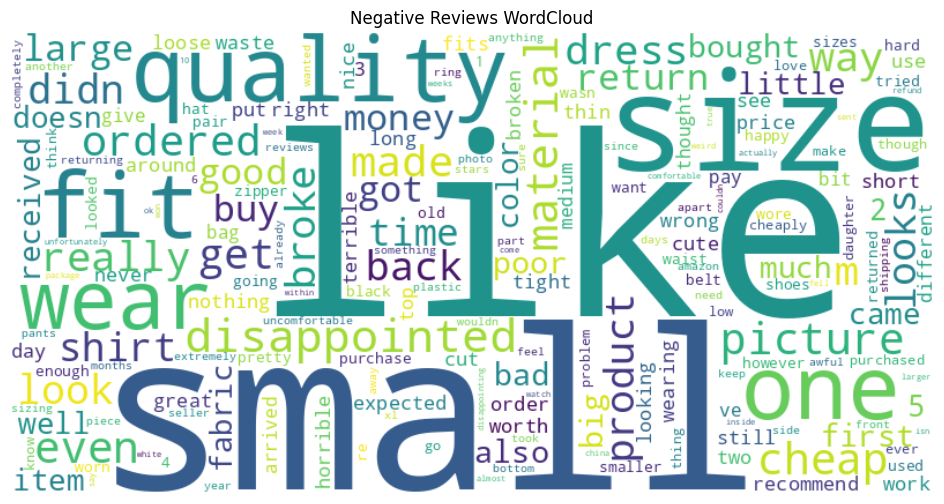

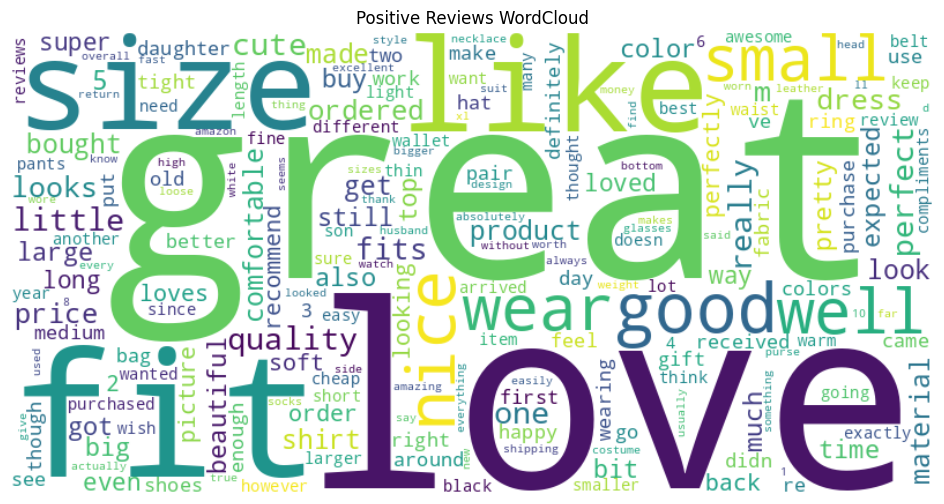

Saved wordcloud images to Drive.


In [ ]:
# Build frequency dict from filtered tokens (use CountVectorizer vocabulary and counts)
# Negative word counts
neg_filtered = cv_model.transform(filtered)  # 'filtered' used earlier for negative sample
# compute frequencies from 'filtered' column
neg_words_rdd = filtered.select("filtered").rdd.flatMap(lambda r: r[0]).map(lambda w: (w,1)).reduceByKey(lambda a,b: a+b)
neg_freq = dict(neg_words_rdd.collect())

# Positive word counts
pos_filtered = cv_model_pos.transform(filtered_pos)
pos_words_rdd = filtered_pos.select("filtered").rdd.flatMap(lambda r: r[0]).map(lambda w: (w,1)).reduceByKey(lambda a,b: a+b)
pos_freq = dict(pos_words_rdd.collect())

# wordclouds
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc_neg = WordCloud(width=800, height=400, background_color="white", max_words=200).generate_from_frequencies(neg_freq)
plt.figure(figsize=(12,6)); plt.imshow(wc_neg, interpolation='bilinear'); plt.axis('off'); plt.title("Negative Reviews WordCloud"); plt.show()

wc_pos = WordCloud(width=800, height=400, background_color="white", max_words=200).generate_from_frequencies(pos_freq)
plt.figure(figsize=(12,6)); plt.imshow(wc_pos, interpolation='bilinear'); plt.axis('off'); plt.title("Positive Reviews WordCloud"); plt.show()

# Save images
wc_neg.to_file("/content/drive/MyDrive/amazon_fashion_wc_negative.png")
wc_pos.to_file("/content/drive/MyDrive/amazon_fashion_wc_positive.png")
print("Saved wordcloud images to Drive.")


Plotting and saving monthly, yearly, rating-vs-sentiment, and top-reviewed charts

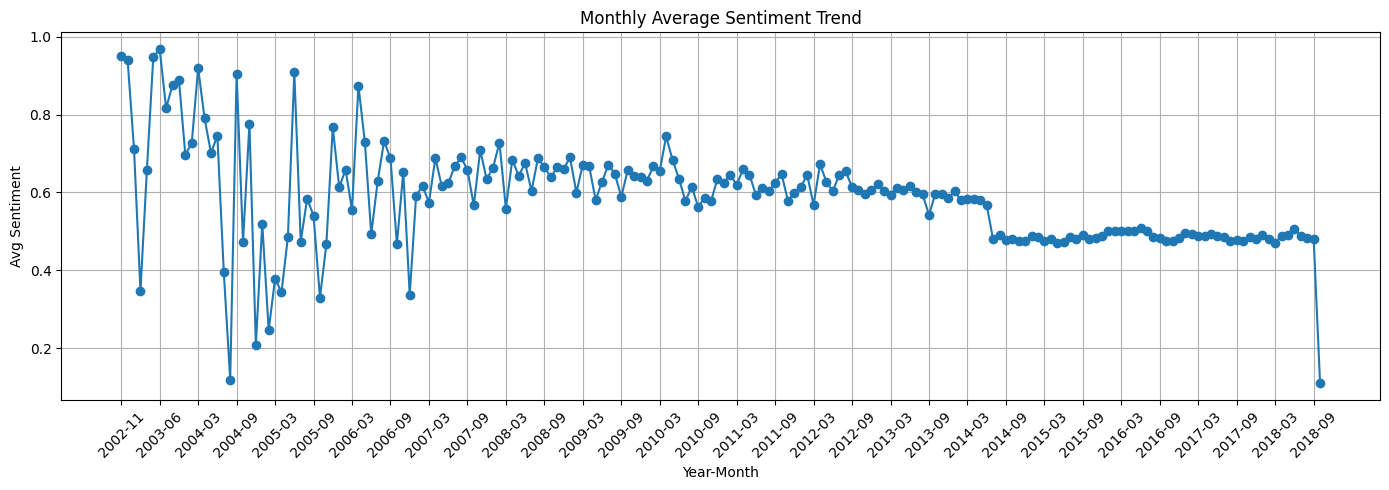

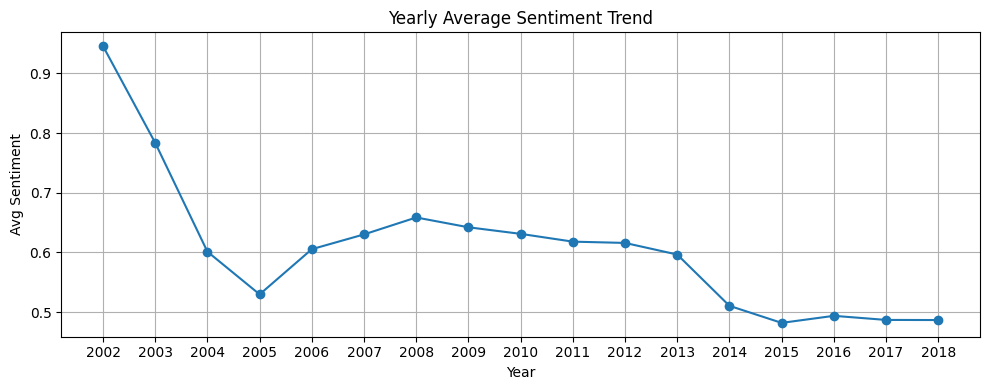

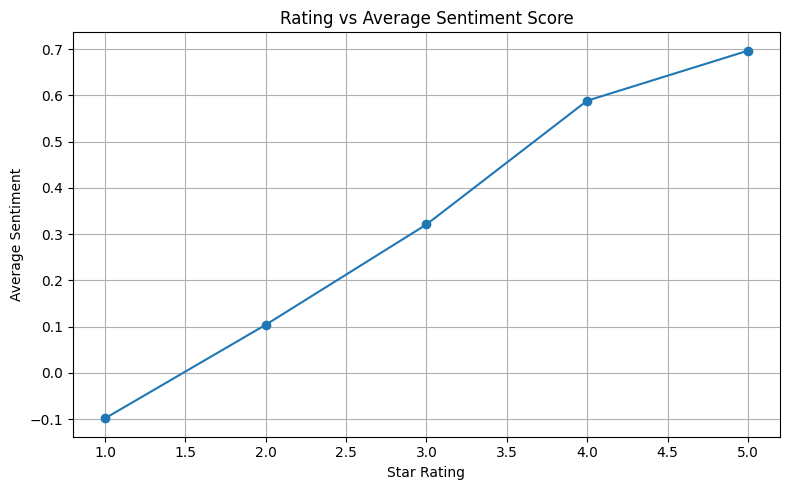

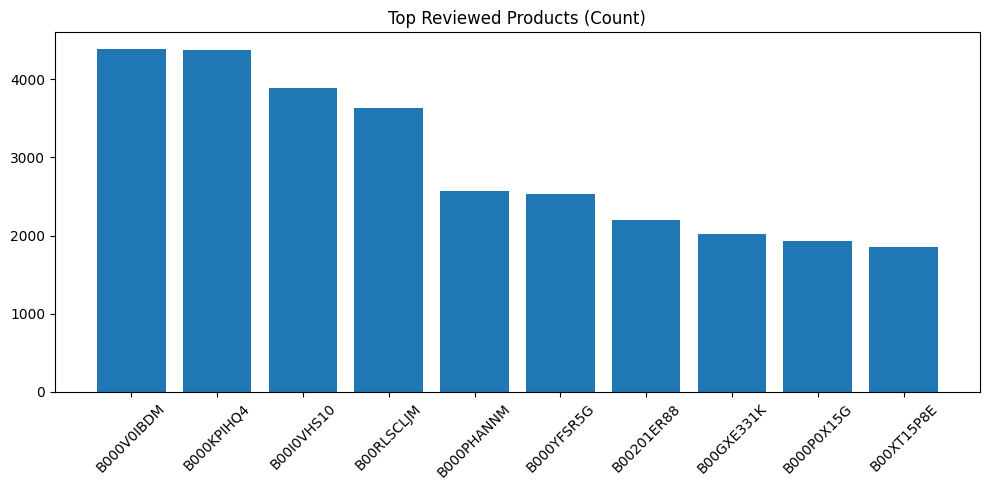

Saved all charts to Drive.


In [ ]:
# monthly_pd already created earlier
import matplotlib.pyplot as plt

# Monthly avg sentiment chart (cleaned x-axis: every 6th)
plt.figure(figsize=(14,5))
plt.plot(monthly_pd['year_month'], monthly_pd['avg(sentiment_score)'], marker='o')
plt.xticks(monthly_pd.index[::6], monthly_pd['year_month'][::6], rotation=45)
plt.title("Monthly Average Sentiment Trend")
plt.xlabel("Year-Month"); plt.ylabel("Avg Sentiment"); plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/amazon_monthly_sentiment.png", dpi=200)
plt.show()

# Clean yearly trend
yearly_sent = (df2.groupBy("year").avg("sentiment_score").orderBy("year"))
yearly_pd = yearly_sent.toPandas()
plt.figure(figsize=(10,4))
plt.plot(yearly_pd['year'], yearly_pd['avg(sentiment_score)'], marker='o')
plt.title("Yearly Average Sentiment Trend")
plt.xlabel("Year"); plt.ylabel("Avg Sentiment"); plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/amazon_yearly_sentiment.png", dpi=200)
plt.show()

# Rating vs sentiment
rating_sent_pd = rating_sent.toPandas()
plt.figure(figsize=(8,5))
plt.plot(rating_sent_pd['rating'], rating_sent_pd['avg_sentiment'], marker='o')
plt.title("Rating vs Average Sentiment Score")
plt.xlabel("Star Rating"); plt.ylabel("Average Sentiment"); plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/amazon_rating_vs_sentiment.png", dpi=200)
plt.show()

# Top reviewed products bar chart (convert)
top_reviewed_pd = top_reviewed.toPandas()
plt.figure(figsize=(10,5))
plt.bar(top_reviewed_pd['asin'].astype(str), top_reviewed_pd['review_count'])
plt.xticks(rotation=45)
plt.title("Top Reviewed Products (Count)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/amazon_top_reviewed.png", dpi=200)
plt.show()

print("Saved all charts to Drive.")


Tokenizing at product level and collecting tokens.

In [ ]:
from pyspark.sql.functions import col, explode, collect_list, size
from pyspark.ml.feature import CountVectorizer, RegexTokenizer, StopWordsRemover

# Step 1: tokenize reviewText per product
tokenizer = RegexTokenizer(inputCol="reviewText", outputCol="words", pattern="\\W")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

df_prod_words = remover.transform(tokenizer.transform(df2))

# Step 2: aggregate words per product
product_words = df_prod_words.groupBy("asin").agg(
    collect_list("filtered_words").alias("all_words")
)

product_words.show(5, truncate=False)


+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|asin      |all_words                                                                                                                                                       

In [ ]:
# create tokenizer & remover (if you already defined them earlier, this will overwrite safely)
tokenizer = RegexTokenizer(inputCol="reviewText", outputCol="words", pattern="\\W")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

# apply on df2 (make a new DF for product-level processing)
reviews_tokens = tokenizer.transform(df2.select("asin","reviewText"))
reviews_tokens = remover.transform(reviews_tokens).select("asin","filtered_words")

# quick check
reviews_tokens.show(3, truncate=80)


+----------+--------------------------------------------------------------------------------+
|      asin|                                                                  filtered_words|
+----------+--------------------------------------------------------------------------------+
|7106116521|                                                               [exactly, needed]|
|7106116521|[agree, review, opening, small, almost, bent, hook, expensive, earrings, tryi...|
|7106116521|[love, going, order, another, pack, keep, work, someone, including, always, l...|
+----------+--------------------------------------------------------------------------------+
only showing top 3 rows



Setting recommender parameters.

In [ ]:
# Parameters for the recommender
MIN_REVIEWS = 50      # consider products with at least 50 reviews
VOCAB_SIZE = 3000     # CountVectorizer vocabulary size
TOP_K = 5             # top K similar products to recommend


Flatten token lists into a single words array per ASIN and keep only products with enough reviews.

In [ ]:
from pyspark.sql.functions import col, explode, collect_list, size, flatten
# aggregate tokens list per asin and compute review_count
prod_words = (
    reviews_tokens.groupBy("asin")
    .agg(collect_list("filtered_words").alias("all_token_lists"))
)

# flatten lists -> a single list per product
prod_words = prod_words.withColumn("words", flatten(col("all_token_lists")))

# compute review_count per product (length of lists)
prod_words = prod_words.withColumn("review_count", size(col("all_token_lists")))

# filter to products with enough reviews
prod_words_filtered = prod_words.filter(col("review_count") >= MIN_REVIEWS)

print("Products considered:", prod_words_filtered.count())
prod_words_filtered.select("asin","review_count").orderBy(col("review_count").desc()).show(10, truncate=False)


Products considered: 1919
+----------+------------+
|asin      |review_count|
+----------+------------+
|B000V0IBDM|4380        |
|B000KPIHQ4|4371        |
|B00I0VHS10|3884        |
|B00RLSCLJM|3633        |
|B000PHANNM|2566        |
|B000YFSR5G|2534        |
|B00201ER88|2202        |
|B00GXE331K|2025        |
|B000P0X15G|1924        |
|B00XT15P8E|1855        |
+----------+------------+
only showing top 10 rows



Vectorize product-level token lists into TF feature vectors (features column) for similarity.

In [ ]:
# CountVectorizer expects an array-of-strings column; we already have "words"
cv = CountVectorizer(inputCol="words", outputCol="features", vocabSize=VOCAB_SIZE, minDF=5)
cv_model = cv.fit(prod_words_filtered)
prod_features = cv_model.transform(prod_words_filtered).select("asin","features","review_count")

# show sample
prod_features.show(5, truncate=False)


+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Converting Spark vectors to NumPy arrays

In [ ]:
import numpy as np
from pyspark.ml.linalg import SparseVector, DenseVector

# safe helper: convert Spark SparseVector/DenseVector -> 1D numpy array
vocab_len = len(cv_model.vocabulary)  # uses your fitted CountVectorizer model

def sparse_to_dense(sv):
    if sv is None:
        return np.zeros(vocab_len, dtype=float)
    # handle pyspark SparseVector
    try:
        if isinstance(sv, SparseVector):
            arr = np.zeros(vocab_len, dtype=float)
            if len(sv.indices) > 0:
                arr[list(sv.indices)] = sv.values
            return arr
        # handle DenseVector
        if isinstance(sv, DenseVector):
            return np.array(sv.toArray(), dtype=float)
        # fallback: try toArray (some types)
        return np.array(sv.toArray(), dtype=float)
    except Exception:
        # last-resort: try simple conversion
        return np.array(sv, dtype=float)

# apply conversion (may take several seconds depending on number of products)
prod_pd['vec'] = prod_pd['features'].apply(sparse_to_dense)

# stack vectors into matrix
matrix = np.vstack(prod_pd['vec'].values)
print("Matrix shape (num_products, vocab_size):", matrix.shape)


Matrix shape (num_products, vocab_size): (1919, 3000)


Computing cosine similarity & extracting top-K similar items.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Normalize rows to avoid scale issues (L2 normalization)
norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-9
matrix_norm = matrix / norms

# compute cosine similarity matrix
sim = cosine_similarity(matrix_norm)   # shape (N, N)
print("Similarity matrix shape:", sim.shape)

# For each product, get top-K similar indices
asin_list = prod_pd['asin'].tolist()

topk_results = []
for i, asin in enumerate(asin_list):
    sims = sim[i]

    # get top indices sorted (descending), skip self
    top_idx = np.argsort(sims)[::-1]
    top_idx = top_idx[top_idx != i]      # remove same index
    top_idx = top_idx[:TOP_K]            # top K

    similar_asins = [asin_list[j] for j in top_idx]
    similar_scores = [float(sims[j]) for j in top_idx]

    topk_results.append((asin, similar_asins, similar_scores))

# Create DataFrame
topk_df = pd.DataFrame(topk_results, columns=['asin','similar_asins','similar_scores'])
topk_df.head()


Similarity matrix shape: (1919, 1919)


,asin,similar_asins,similar_scores
0,B00062NHH0,"[B00ACIFQGS, B00BIZUBOG, B00HZ31VBC, B00HZ3DG5...","[0.920180206600183, 0.8815098212965166, 0.8720..."
1,B0007MV6PO,"[B0007MV6PY, B005GKDL9G, B00NIVAEG8, B0007MV6Q...","[0.9180093291358248, 0.8996916326251245, 0.896..."
2,B0007MV6Q8,"[B0007MV6PY, B00NIVAEG8, B005GKDL9G, B0007MV6P...","[0.9332914175748748, 0.9217415039383853, 0.900..."
3,B0009M96EK,"[B00UPN42RY, B01HEISONU, B00TE3DO7A, B0018N8YU...","[0.7486876937829079, 0.6839166713238661, 0.665..."
4,B0009NYJF0,"[B0064CRCWW, B0018N7NP8, B0018N66X8, B004O8M30...","[0.7913141569039406, 0.7297107694418057, 0.729..."


Formatting similar ASINs/scores into strings, save the final CSV to Drive, and display sample rows for verification.

In [ ]:
topk_df['similar_asins_str'] = topk_df['similar_asins'].apply(lambda lst: "|".join(lst))
topk_df['similar_scores_str'] = topk_df['similar_scores'].apply(lambda lst: "|".join([f"{s:.4f}" for s in lst]))

out_pd = topk_df[['asin','similar_asins_str','similar_scores_str']]
out_pd.to_csv("/content/drive/MyDrive/amazon_fashion_similar_products.csv", index=False)
print("Saved similar-products CSV to Drive: /content/drive/MyDrive/amazon_fashion_similar_products.csv")

# show top 5 rows
out_pd.head()


Saved similar-products CSV to Drive: /content/drive/MyDrive/amazon_fashion_similar_products.csv


,asin,similar_asins_str,similar_scores_str
0,B00062NHH0,B00ACIFQGS|B00BIZUBOG|B00HZ31VBC|B00HZ3DG5Q|B0...,0.9202|0.8815|0.8720|0.8694|0.8691
1,B0007MV6PO,B0007MV6PY|B005GKDL9G|B00NIVAEG8|B0007MV6Q8|B0...,0.9180|0.8997|0.8964|0.8949|0.8943
2,B0007MV6Q8,B0007MV6PY|B00NIVAEG8|B005GKDL9G|B0007MV6PO|B0...,0.9333|0.9217|0.9006|0.8949|0.8912
3,B0009M96EK,B00UPN42RY|B01HEISONU|B00TE3DO7A|B0018N8YUG|B0...,0.7487|0.6839|0.6656|0.6538|0.6417
4,B0009NYJF0,B0064CRCWW|B0018N7NP8|B0018N66X8|B004O8M304|B0...,0.7913|0.7297|0.7297|0.7180|0.7134
